In [36]:
import numpy as np

For the forward measurement:


In [37]:
def round_unc(value, uncertainty, cutoff=2, extract_magnitude=False):
    scalar_input = np.isscalar(value)

    value = np.atleast_1d(value).astype(float)
    uncertainty = np.atleast_1d(uncertainty).astype(float)

    exp = np.floor(np.log10(np.abs(uncertainty)))
    first_digit = (uncertainty / 10**exp).astype(int)
    sigs = np.where(first_digit <= cutoff, 2, 1)

    rounding_decimals = (-exp + (sigs - 1)).astype(int)
    rounded_uncertainty = (
        np.round(uncertainty * 10.0**rounding_decimals) / 10.0**rounding_decimals
    )

    decimals = (-np.floor(np.log10(rounded_uncertainty)) + (sigs - 1)).astype(int)
    rounded_value = np.round(value * 10.0**decimals) / 10.0**decimals

    if extract_magnitude:
        exponent = np.floor(np.log10(np.abs(rounded_value))).astype(int)
        mantissa_value = rounded_value / 10.0**exponent
        mantissa_uncertainty = rounded_uncertainty / 10.0**exponent

        if scalar_input:
            return mantissa_value[0], mantissa_uncertainty[0], exponent[0]
        return mantissa_value, mantissa_uncertainty, exponent

    if scalar_input:
        return rounded_value[0], rounded_uncertainty[0]
    return rounded_value, rounded_uncertainty



In [38]:
vals = np.array([998, 1037])
errs = np.sqrt(vals)
vals, errs

(array([ 998, 1037]), array([31.591138  , 32.20248438]))

In [40]:
round_unc(vals, errs, extract_magnitude=True)

(array([1.  , 1.04]), array([0.03, 0.03]), array([3, 3]))

In [41]:
0.04 / 0.06

0.6666666666666667

In [42]:
np.sqrt(20)

np.float64(4.47213595499958)

In [43]:
np.array([20, 4]) / 6

array([3.33333333, 0.66666667])

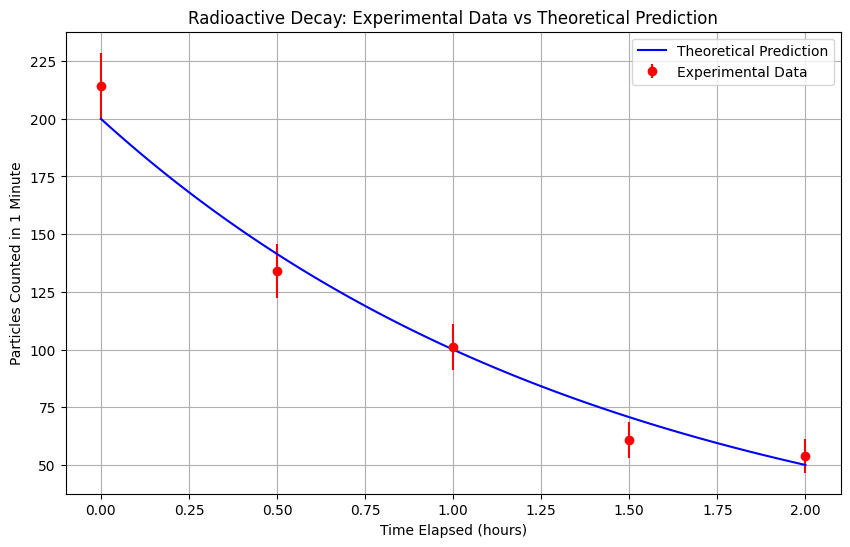

In [45]:
# %% cell 9 code
import numpy as np
import matplotlib.pyplot as plt

# Data
times = np.array([0.0, 0.5, 1.0, 1.5, 2.0])
particles = np.array([214, 134, 101, 61, 54])

# Calculate uncertainties (assuming Poisson statistics)
particle_errors = np.sqrt(particles)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot experimental data with error bars
plt.errorbar(times, particles, yerr=particle_errors, fmt='ro', label='Experimental Data')

# Theoretical curve parameters
v0 = 200
r = 0.693

# Generate a smooth theoretical curve
times_smooth = np.linspace(0, 2, 100)
theory_particles = v0 * np.exp(-r * times_smooth)
plt.plot(times_smooth, theory_particles, 'b-', label='Theoretical Prediction')

plt.xlabel('Time Elapsed (hours)')
plt.ylabel('Particles Counted in 1 Minute')
plt.title('Radioactive Decay: Experimental Data vs Theoretical Prediction')
plt.legend()
plt.grid(True)
plt.show()


In [46]:
# Problem 3.5b
val_b = 13
unc_b = val_b * (1/5 + 2/8)
print("Problem 3.5b:")
print(f"{val_b} ± {unc_b:.4f}")
print(f"= {val_b} ± {unc_b:.4f} -> Range: [{val_b - unc_b:.4f}, {val_b + unc_b:.4f}]")
print()

# Problem 3.5c
val_c = 30
unc_c = val_c * (1/10 + 2/20)
print("Problem 3.5c:")
print(f"{val_c} ± {unc_c:.4f}")
print(f"= {val_c} ± {unc_c:.4f} -> Range: [{val_c - unc_c:.4f}, {val_c + unc_c:.4f}]")

Problem 3.5b:
13 ± 5.8500
= 13 ± 5.8500 -> Range: [7.1500, 18.8500]

Problem 3.5c:
30 ± 6.0000
= 30 ± 6.0000 -> Range: [24.0000, 36.0000]


In [47]:
val = 50 / 5.0
unc = val * ((1 / 50) + (0.1 / 5.0))

print(f"{val:.4f} ± {unc:.4f}")
print(f"Range: [{val - unc:.4f}, {val + unc:.4f}]")

10.0000 ± 0.4000
Range: [9.6000, 10.4000]


In [48]:
val = 30 * 10.0
unc = val * ((1 / 30) + (0.4 / 10.0))

print(f"{val:.4f} ± {unc:.4f}")
print(f"Range: [{val - unc:.4f}, {val + unc:.4f}]")

300.0000 ± 22.0000
Range: [278.0000, 322.0000]


In [49]:
val = (1 / 52) * 0.590
unc = (1 / 52) * 0.005

print(f"{val:.6f} ± {unc:.6f}")
print(f"Range: [{val - unc:.6f}, {val + unc:.6f}]")

0.011346 ± 0.000096
Range: [0.011250, 0.011442]


In [50]:
# Given values
g = 9.80  # m/s^2
t = 3.0   # s
delta_t = 0.3  # s

# Calculate distance
d = 0.5 * g * t**2

# Calculate uncertainty
delta_d = g * t * delta_t

print(f"d = {d:.4f} m")
print(f"δd = {delta_d:.4f} m")
print(f"Range: [{d - delta_d:.4f}, {d + delta_d:.4f}] m")

d = 44.1000 m
δd = 8.8200 m
Range: [35.2800, 52.9200] m


In [51]:

import numpy as np

def propagate_errors_dependent(partials, uncertainties):
    """
    Calculate uncertainty for dependent (non-independent) errors.
    Uses maximum error method: sum of absolute values.
    """
    return sum(abs(p) * u for p, u in zip(partials, uncertainties))

def propagate_errors_independent(partials, uncertainties):
    """
    Calculate uncertainty for independent random errors.
    Uses quadrature method: square root of sum of squares.
    """
    return np.sqrt(sum((p * u)**2 for p, u in zip(partials, uncertainties)))

print("Problem 3.5 - Error Propagation Using Partial Derivatives")
print("=" * 70)

# (a) (5 ± 1) + (8 ± 2) - (10 ± 4)
print("\n(a) (5 ± 1) + (8 ± 2) - (10 ± 4)")
x, dx = 5, 1
y, dy = 8, 2
z, dz = 10, 4

result_a = x + y - z
partials_a = [1, 1, -1]
uncertainties_a = [dx, dy, dz]

error_dep_a = propagate_errors_dependent(partials_a, uncertainties_a)
error_indep_a = propagate_errors_independent(partials_a, uncertainties_a)

print(f"Result: {result_a}")
print(f"Dependent errors: ±{error_dep_a:.4f}")
print(f"Independent errors: ±{error_indep_a:.4f}")

# (b) (5 ± 1) × (8 ± 2)
print("\n(b) (5 ± 1) × (8 ± 2)")
x, dx = 5, 1
y, dy = 8, 2

result_b = x * y
partials_b = [y, x]
uncertainties_b = [dx, dy]

error_dep_b = propagate_errors_dependent(partials_b, uncertainties_b)
error_indep_b = propagate_errors_independent(partials_b, uncertainties_b)

print(f"Result: {result_b}")
print(f"Dependent errors: ±{error_dep_b:.4f}")
print(f"Independent errors: ±{error_indep_b:.4f}")

# (c) (10 ± 1)/(20 ± 2)
print("\n(c) (10 ± 1)/(20 ± 2)")
x, dx = 10, 1
y, dy = 20, 2

result_c = x / y
partials_c = [1/y, -x/(y**2)]
uncertainties_c = [dx, dy]

error_dep_c = propagate_errors_dependent(partials_c, uncertainties_c)
error_indep_c = propagate_errors_independent(partials_c, uncertainties_c)

print(f"Result: {result_c:.4f}")
print(f"Dependent errors: ±{error_dep_c:.4f}")
print(f"Independent errors: ±{error_indep_c:.4f}")

# (d) (30 ± 1) × (50 ± 1)/(5.0 ± 0.1)
print("\n(d) (30 ± 1) × (50 ± 1)/(5.0 ± 0.1)")
x, dx = 30, 1
y, dy = 50, 1
z, dz = 5.0, 0.1

result_d = (x * y) / z
partials_d = [y/z, x/z, -(x*y)/(z**2)]
uncertainties_d = [dx, dy, dz]

error_dep_d = propagate_errors_dependent(partials_d, uncertainties_d)
error_indep_d = propagate_errors_independent(partials_d, uncertainties_d)

print(f"Result: {result_d:.4f}")
print(f"Dependent errors: ±{error_dep_d:.4f}")
print(f"Independent errors: ±{error_indep_d:.4f}")

print("\n" + "=" * 70)
print("Summary Table:")
print("=" * 70)
print(f"{'Problem':<15} {'Result':<15} {'Dependent':<15} {'Independent':<15}")
print("-" * 70)
print(f"{'(a)':<15} {result_a:<15.4f} {error_dep_a:<15.4f} {error_indep_a:<15.4f}")
print(f"{'(b)':<15} {result_b:<15.4f} {error_dep_b:<15.4f} {error_indep_b:<15.4f}")
print(f"{'(c)':<15} {result_c:<15.4f} {error_dep_c:<15.4f} {error_indep_c:<15.4f}")
print(f"{'(d)':<15} {result_d:<15.4f} {error_dep_d:<15.4f} {error_indep_d:<15.4f}")
print("=" * 70)

Problem 3.5 - Error Propagation Using Partial Derivatives

(a) (5 ± 1) + (8 ± 2) - (10 ± 4)
Result: 3
Dependent errors: ±7.0000
Independent errors: ±4.5826

(b) (5 ± 1) × (8 ± 2)
Result: 40
Dependent errors: ±18.0000
Independent errors: ±12.8062

(c) (10 ± 1)/(20 ± 2)
Result: 0.5000
Dependent errors: ±0.1000
Independent errors: ±0.0707

(d) (30 ± 1) × (50 ± 1)/(5.0 ± 0.1)
Result: 300.0000
Dependent errors: ±22.0000
Independent errors: ±13.1149

Summary Table:
Problem         Result          Dependent       Independent    
----------------------------------------------------------------------
(a)             3.0000          7.0000          4.5826         
(b)             40.0000         18.0000         12.8062        
(c)             0.5000          0.1000          0.0707         
(d)             300.0000        22.0000         13.1149        


In [52]:
import math

# (a)
result_a = math.sqrt((1 * 1)**2 + (1 * 2)**2 + (-1 * 4)**2)
print(f"(a) {result_a}")

# (b)
result_b = math.sqrt((8 * 1)**2 + (5 * 2)**2)
print(f"(b) {result_b}")

# (c)
result_c = math.sqrt((1/20 * 1)**2 + (-10/400 * 2)**2)
print(f"(c) {result_c}")

# (d)
result_d = math.sqrt((50/5 * 1)**2 + (30/5 * 1)**2 + (-1500/25 * 0.1)**2)
print(f"(d) {result_d}")

(a) 4.58257569495584
(b) 12.806248474865697
(c) 0.07071067811865477
(d) 13.114877048604


In [53]:
import math

result = math.sqrt(
    (50 / 5 * 1) ** 2 +
    (30 / 5 * 1) ** 2 +
    (-1500 / 25 * 0.1) ** 2
)

print(result)

13.114877048604


In [54]:
value = 40
uncertainty = 40 * (1/5 + 2/8)

print(f"{value} ± {uncertainty}")

40 ± 18.0


In [61]:
40 * (1/5 + 2/8)

18.0

In [62]:
0.5 * (1/10 + 2/20)

0.1

In [60]:
value = 0.5
uncertainty = 0.5 * (1/10 + 2/20)

print(f"{value} ± {uncertainty}")

0.5 ± 0.1


In [56]:
# Values
numerator = 50
delta_numerator = 1

denominator = 5.0
delta_denominator = 0.1

# Division
value = numerator / denominator

# Propagated uncertainty
uncertainty = value * (delta_numerator / numerator + delta_denominator / denominator)

print(f"{value} ± {uncertainty}")

10.0 ± 0.4


In [57]:
2 * 2 * 4

16

In [58]:
30 * (1/30 + 0.4/10)

2.2

In [63]:
10 * (1/50 + 0.1 / 5)

0.4

In [64]:
# 10 \pm 0.4
300 * (1/30 + 0.4/10)

22.0

In [65]:
0.590 / 52

0.011346153846153846

In [66]:
250 / 52

4.8076923076923075